# Does order-book imbalance predict short-horizon returns?

**Question.** Order-book imbalance (OBI) — the normalized difference between resting bid and ask
volume, $\mathrm{OBI} = (V_b - V_a)/(V_b + V_a)$ — is the canonical short-horizon pressure signal:
a bid-heavy book should precede upward mid moves. Does that hold in live BTCUSDT data, at what
horizon, and is the effect large enough to matter against the spread?

**Data.** Binance BTCUSDT depth diffs (100&nbsp;ms) + trades, captured with `lob.ingest.binance`
and replayed through the C++ matching engine with `lob.ingest.l2` — the book is reconstructed
level-by-level inside the engine, and every signal row below (mid, spread, OBI over the top 5
levels, CVD) comes out of that reconstruction.

**Method.** Align book snapshots to a 100&nbsp;ms wall-clock grid, compute forward mid returns at
1&nbsp;s / 5&nbsp;s / 10&nbsp;s horizons, then look at rank correlation (information coefficient) and
OBI-decile conditional means. Caveats are collected at the end — they matter as much as the plots.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lob.ingest import read_jsonl, replay_l2

CAPTURE = Path(os.environ.get("LOB_CAPTURE", "../data/btcusdt_10min.jsonl"))

res = replay_l2(read_jsonl(CAPTURE), tick_size=0.01, qty_step=1e-5, depth_levels=5)
print(f"capture: {CAPTURE.name}")
print(
    f"depth events: {res.stats.depth_events}, trades: {res.stats.trades}, "
    f"gaps: {res.stats.gaps}, stale dropped: {res.stats.dropped_stale}, "
    f"crossed adds skipped: {res.stats.crossed_adds_skipped}"
)

df = pd.DataFrame(res.records)
df["ts"] = pd.to_datetime(df["ts"], unit="ms")
df = df.set_index("ts")[["mid", "obi", "spread", "cvd"]].dropna(subset=["mid", "obi"])
df = df[~df.index.duplicated(keep="last")]
span = (df.index[-1] - df.index[0]).total_seconds()
print(f"{len(df)} book snapshots over {span:.0f}s")
df.head()

capture: btcusdt_10min.jsonl
depth events: 5087, trades: 27264, gaps: 0, stale dropped: 11, crossed adds skipped: 0
5087 book snapshots over 509s


,mid,obi,spread,cvd
ts,,,,
2026-07-02 16:07:32.714,61608.005,-0.913670,0.01,-0.01620
2026-07-02 16:07:32.814,61608.005,-0.921362,0.01,-0.01620
2026-07-02 16:07:32.914,61608.005,-0.623523,0.01,-0.04229
2026-07-02 16:07:33.014,61608.005,-0.506395,0.01,-0.04289
2026-07-02 16:07:33.114,61608.005,-0.553487,0.01,-0.04289


Book updates arrive in event time; forward returns need wall-clock time. Resampling to a 100&nbsp;ms
grid (forward-filling through quiet gaps of up to 5&nbsp;s) puts every observation on the same clock,
so a "5&nbsp;s forward return" means the same thing everywhere. Returns are in basis points of the mid.

In [2]:
grid = df.resample("100ms").last().ffill(limit=50).dropna(subset=["mid", "obi"])

HORIZONS = {"1s": 10, "5s": 50, "10s": 100}
for name, steps in HORIZONS.items():
    grid[f"fwd_{name}"] = (grid["mid"].shift(-steps) / grid["mid"] - 1) * 1e4
grid = grid.dropna()
print(f"{len(grid)} grid points after forward-return alignment")

4987 grid points after forward-return alignment


In [3]:
ic = pd.Series(
    {name: grid["obi"].corr(grid[f"fwd_{name}"], method="spearman") for name in HORIZONS},
    name="Spearman IC: OBI vs forward mid return",
)
ic.round(4).to_frame()

,Spearman IC: OBI vs forward mid return
1s,0.5730
5s,0.5375
10s,0.4513


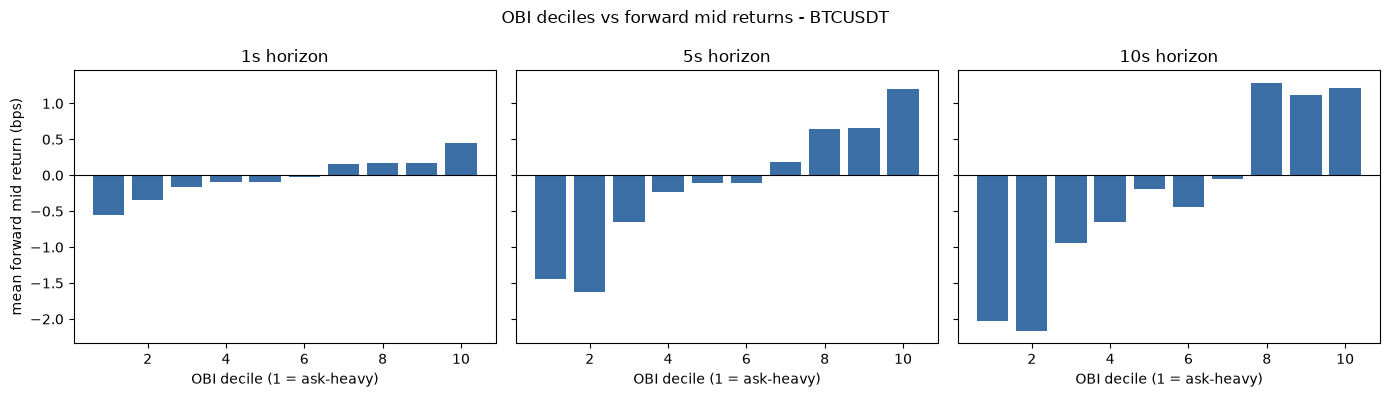

In [4]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(14, 4), sharey=True)
for ax, name in zip(axes, HORIZONS):
    buckets = pd.qcut(grid["obi"], 10, labels=False, duplicates="drop")
    means = grid.groupby(buckets)[f"fwd_{name}"].mean()
    ax.bar(means.index.astype(int) + 1, means.values, color="#3b6ea5")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{name} horizon")
    ax.set_xlabel("OBI decile (1 = ask-heavy)")
axes[0].set_ylabel("mean forward mid return (bps)")
fig.suptitle("OBI deciles vs forward mid returns - BTCUSDT")
plt.tight_layout()
plt.show()

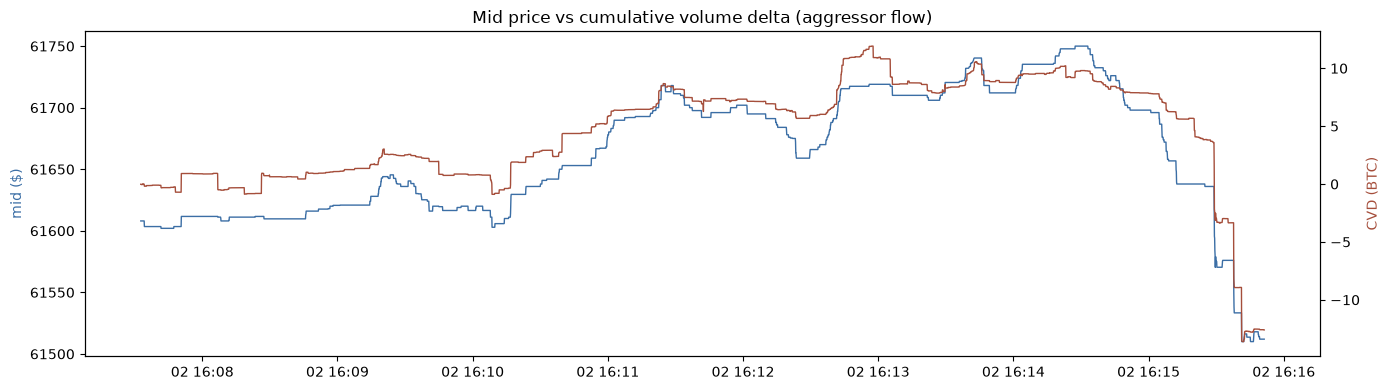

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 4))
ax1.plot(grid.index, grid["mid"], color="#3b6ea5", lw=1)
ax1.set_ylabel("mid ($)", color="#3b6ea5")
ax2 = ax1.twinx()
ax2.plot(grid.index, grid["cvd"], color="#a54e3b", lw=1)
ax2.set_ylabel("CVD (BTC)", color="#a54e3b")
ax1.set_title("Mid price vs cumulative volume delta (aggressor flow)")
plt.tight_layout()
plt.show()

In [6]:
half_spread_bps = grid["spread"] / grid["mid"] / 2 * 1e4
top = grid[grid["obi"] > grid["obi"].quantile(0.9)]
bot = grid[grid["obi"] < grid["obi"].quantile(0.1)]

pd.DataFrame(
    {
        "value": [
            top["fwd_5s"].mean(),
            bot["fwd_5s"].mean(),
            top["fwd_5s"].mean() - bot["fwd_5s"].mean(),
            half_spread_bps.median(),
        ]
    },
    index=[
        "mean 5s fwd return, top OBI decile (bps)",
        "mean 5s fwd return, bottom OBI decile (bps)",
        "top-bottom spread (bps)",
        "median half-spread (bps)",
    ],
).round(3)

,value
"mean 5s fwd return, top OBI decile (bps)",1.206
"mean 5s fwd return, bottom OBI decile (bps)",-1.447
top-bottom spread (bps),2.653
median half-spread (bps),0.001


## Results

Over this 8.5-minute BTCUSDT session (5,087 book snapshots, 27k trades, zero sync gaps):

- **The IC is large and decays with horizon**: Spearman rank correlation between OBI and forward
  mid returns of **0.57 at 1s, 0.54 at 5s, 0.45 at 10s**. The decile chart is close to monotonic:
  ask-heavy books precede down-moves, bid-heavy books precede up-moves. This is consistent with the
  literature (e.g. Cont, Kukanov & Stoikov on order-flow imbalance) - at these horizons the book
  really does telegraph the next mid move.
- **The signal clears the spread but not the fees.** Top-minus-bottom OBI decile = **+2.65 bps over
  5s**, against a median half-spread of ~0.001 bps (one cent on a ~$61.6k mid). Taker fees on
  Binance (~10 bps for retail) are ~4x the decile spread, so aggressively trading this signal loses
  money after costs. A maker implementation avoids the fee but inherits queue risk and adverse
  selection - exactly the trade-off market-making research is about.

**Why the IC looks so much larger than equity-market values (~0.05-0.15):**

1. **Overlapping windows.** Consecutive 100 ms observations share most of their forward window, so
   the effective sample size is far below the 4,987 row count; the IC is descriptive here, not a
   t-stat. Non-overlapping sampling would shrink confidence dramatically.
2. **Mechanical coupling at the touch.** OBI over the top levels partly *is* the next mid move:
   when the best level empties, the mid ticks by construction. Deeper-book OBI or
   quote-stuffing-robust variants weaken this.
3. **One session, one regime.** A single 8.5-minute continuous capture from one venue. A real study
   stacks many sessions across days and volatility regimes.
4. **L2 reconstruction.** Binance publishes aggregate levels, not individual orders; queue position
   and order-level dynamics are invisible.

**Extensions this repo supports:** longer multi-session captures (`python -m lob.ingest.binance`),
OBI at different depth windows (`depth_levels` in `replay_l2`), CVD as a complementary flow signal,
and non-overlapping sampling for honest inference.